In [45]:
%pip install ipykernel datasets pandas numpy matplotlib seaborn torch transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, multilabel_confusion_matrix

# 1. Dataset Selection & Sampling (Rubric Requirement)
# We sample 5000 rows for training and 1000 for validation/testing to speed up execution
dataset = load_dataset("nvidia/Aegis-AI-Content-Safety-Dataset-2.0")
train_data = dataset['train'].shuffle(seed=42).select(range(5000))
val_data = dataset['test'].shuffle(seed=42).select(range(1000))

# 12 Core Safety Categories
labels = ['Controlled/Regulated Substances', 'Criminal Planning/Confessions', 'Deception/Fraud', 
          'Guns and Illegal Weapons', 'Harassment', 'Hate/Identity Hate', 'PII/Privacy', 
          'Profanity', 'Sexual', 'Suicide and Self Harm', 'Threat', 'Violence']
label2idx = {label: idx for idx, label in enumerate(labels)}

# 2. Text Preprocessing (Tokenization, Padding, Truncation)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

class AegisDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.num_classes = len(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        text = str(item['prompt']) + " [SEP] " + str(item['response'])
        raw_labels = str(item['violated_categories'])

        # Fixed-length padding/truncation
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )

        y_tensor = torch.zeros(self.num_classes, dtype=torch.float32)
        if raw_labels and str(raw_labels).lower() not in ['none', 'nan']:
            categories = [cat.strip() for cat in raw_labels.split(',')]
            for cat in categories:
                if cat in label2idx:
                    y_tensor[label2idx[cat]] = 1.0

        return {'input_ids': encoding['input_ids'].flatten(), 'targets': y_tensor}

train_loader = DataLoader(AegisDataset(train_data, tokenizer), batch_size=32, shuffle=True)
val_loader = DataLoader(AegisDataset(val_data, tokenizer), batch_size=32, shuffle=False)

In [48]:
# 3. Model Design (Embedding, Conv1D, MaxPool, Dense, Dropout Bonus)
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, kernel_sizes=[3, 4, 5], num_filters=100):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # Parallel convolutional layers with different kernel sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k) 
            for k in kernel_sizes
        ])
        
        # Bonus Requirement: Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, num_classes)

    def forward(self, x):
        embedded = self.embedding(x).permute(0, 2, 1) 
        
        conv_results = []
        for conv in self.convs:
            c = F.relu(conv(embedded)) 
            pooled = F.max_pool1d(c, c.shape[2]).squeeze(2) 
            conv_results.append(pooled)
            
        cat = torch.cat(conv_results, dim=1)
        dropped = self.dropout(cat)
        return self.fc(dropped)

model = TextCNN(vocab_size=tokenizer.vocab_size, embed_dim=128, num_classes=len(labels))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [52]:
# 4. Training (Loss Function, Optimizer, Tracking)
# Calculate rough positive weights (Total negative samples / Total positive samples per class)
# For simplicity, if a class is 5% of your data, you can weight it by 20.
# We pass a tensor of 12 weights (one for each class)
weights = torch.tensor([10.0, 5.0, 20.0, 20.0, 15.0, 15.0, 20.0, 20.0, 15.0, 20.0, 30.0, 10.0])
weights = weights.to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5

train_losses, val_losses = [], []

for epoch in range(epochs):
    # Training Phase
    model.train()
    batch_train_loss = []
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        targets = batch['targets'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        batch_train_loss.append(loss.item())
        
    train_losses.append(np.mean(batch_train_loss))
    
    # Validation Phase
    model.eval()
    batch_val_loss = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            targets = batch['targets'].to(device)
            logits = model(input_ids)
            loss = criterion(logits, targets)
            batch_val_loss.append(loss.item())
            
    val_losses.append(np.mean(batch_val_loss))
    print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Epoch 1 | Train Loss: 0.6503 | Val Loss: 0.7852
Epoch 2 | Train Loss: 0.5467 | Val Loss: 0.8185
Epoch 3 | Train Loss: 0.4880 | Val Loss: 0.8685
Epoch 4 | Train Loss: 0.4464 | Val Loss: 0.8440
Epoch 5 | Train Loss: 0.4066 | Val Loss: 0.8799


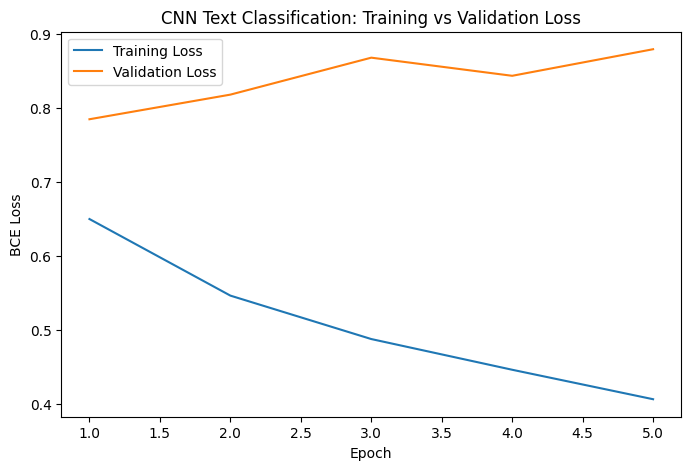


--- Classification Report ---
                                 precision    recall  f1-score   support

Controlled/Regulated Substances       0.34      0.60      0.43        48
  Criminal Planning/Confessions       0.60      0.81      0.69       255
                Deception/Fraud       0.00      0.00      0.00         0
       Guns and Illegal Weapons       0.16      0.44      0.24        25
                     Harassment       0.13      0.86      0.23        76
             Hate/Identity Hate       0.20      0.78      0.32        86
                    PII/Privacy       0.53      0.65      0.58        51
                      Profanity       0.16      0.84      0.27        57
                         Sexual       0.31      0.67      0.43        58
          Suicide and Self Harm       0.12      0.84      0.21        25
                         Threat       0.50      0.14      0.22         7
                       Violence       0.22      0.72      0.33        81

                  

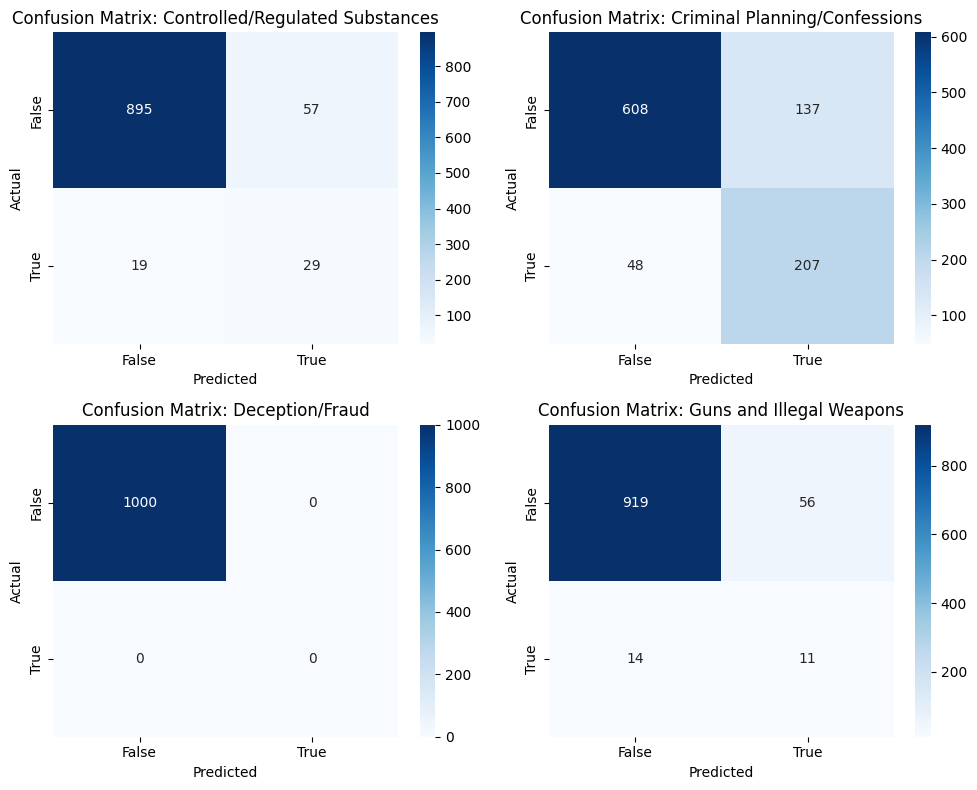

In [54]:
# 5. Evaluation and Visualizations
# Plot Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.title('CNN Text Classification: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.show()

# Generate Predictions for Metrics
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for batch in val_loader:
        logits = model(batch['input_ids'].to(device))
        preds = (torch.sigmoid(logits) > 0.25).float()
        all_preds.append(preds.cpu().numpy())
        all_targets.append(batch['targets'].numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=labels, zero_division=0))

# Multi-label Confusion Matrix Heatmap (Plotting first 4 categories for space)
mcm = multilabel_confusion_matrix(all_targets, all_preds)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['False', 'True'], yticklabels=['False', 'True'])
    ax.set_title(f'Confusion Matrix: {labels[i]}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()